In [4]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\muska\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

df = pd.read_csv("TA13.csv")

df.head()

,offering_id,user_id,overall,value,service,location,rooms,cleanliness,sleep_quality,review_text
0,1762573,FB1032DECE1162CB3556D05F278AAFFD,4.0,4.0,4.0,5.0,4.0,5.0,4.0,“Great Stay” This is a great property in Midto...
1,1762573,BA524A238B1171206691A6CC3F28F266,4.0,3.0,4.0,5.0,5.0,5.0,5.0,“Its the best of the Andaz Brand in the US.......
2,1456560,EC6CB11E9DC8761710DDA3CF48DD995F,4.0,4.0,4.0,5.0,4.0,5.0,5.0,“A Nice Stay for NYC!” This hotel is a nice st...
3,1762573,C81AB7D49D98FA410EA191E15F427BEC,4.0,5.0,4.0,5.0,5.0,5.0,5.0,“Stunningly Wonderful!” Other hotels in NYC th...
4,1456560,2404E3630B78BB9E8D6583076FBA0742,4.0,4.0,4.0,4.0,4.0,4.0,5.0,"“Modern, minimalist, central hotel” We got a r..."


In [6]:
df.shape


(80122, 10)

In [7]:
df.columns


Index(['offering_id', 'user_id', 'overall', 'value', 'service', 'location',
       'rooms', 'cleanliness', 'sleep_quality', 'review_text'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80122 entries, 0 to 80121
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   offering_id    80122 non-null  int64  
 1   user_id        80122 non-null  object 
 2   overall        80122 non-null  float64
 3   value          72861 non-null  float64
 4   service        72494 non-null  float64
 5   location       64545 non-null  float64
 6   rooms          67724 non-null  float64
 7   cleanliness    72979 non-null  float64
 8   sleep_quality  45586 non-null  float64
 9   review_text    80122 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 6.1+ MB


Data cleaning


In [9]:
df.isnull().sum()

offering_id          0
user_id              0
overall              0
value             7261
service           7628
location         15577
rooms            12398
cleanliness       7143
sleep_quality    34536
review_text          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
rating_cols = [
    'value','service','location',
    'rooms','cleanliness','sleep_quality'
]

for col in rating_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\muska\AppData\Local\Temp\ipykernel_11752\158085264.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [13]:
df.isnull().sum()

offering_id      0
user_id          0
overall          0
value            0
service          0
location         0
rooms            0
cleanliness      0
sleep_quality    0
review_text      0
dtype: int64

In [14]:
df['review_length'] = df['review_text'].apply(lambda x: len(str(x).split()))

In [15]:
df[['review_text','review_length']].head()

,review_text,review_length
0,“Great Stay” This is a great property in Midto...,95
1,“Its the best of the Andaz Brand in the US.......,471
2,“A Nice Stay for NYC!” This hotel is a nice st...,91
3,“Stunningly Wonderful!” Other hotels in NYC th...,174
4,"“Modern, minimalist, central hotel” We got a r...",146


EDA

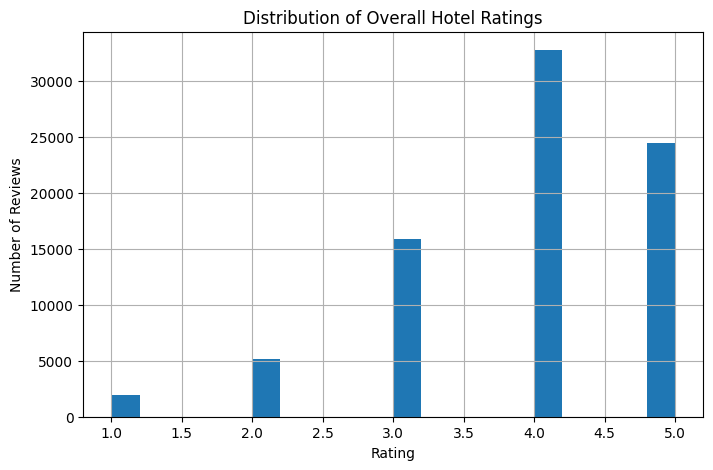

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['overall'].hist(bins=20)

plt.title("Distribution of Overall Hotel Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()


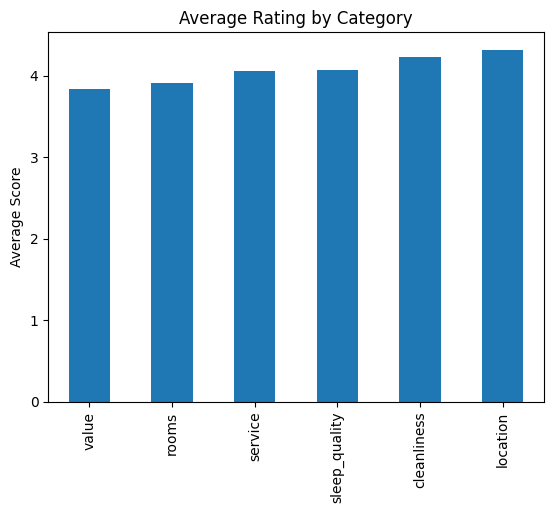

In [17]:
rating_cols = [
    'value','service','location',
    'rooms','cleanliness','sleep_quality'
]

df[rating_cols].mean().sort_values().plot(kind='bar')

plt.title("Average Rating by Category")
plt.ylabel("Average Score")
plt.show()

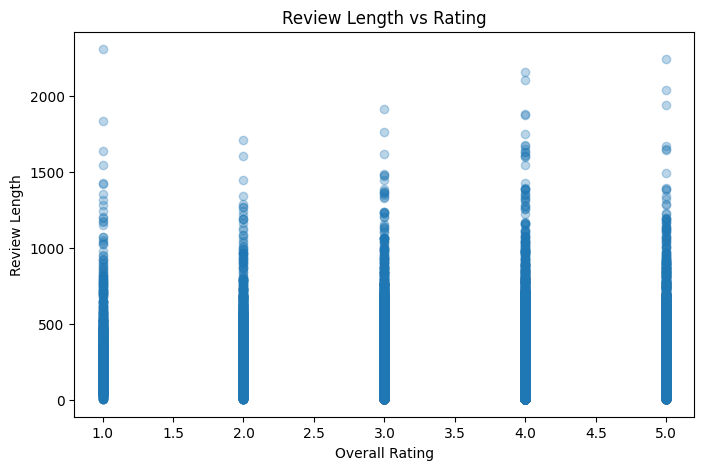

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df['overall'], df['review_length'], alpha=0.3)

plt.xlabel("Overall Rating")
plt.ylabel("Review Length")
plt.title("Review Length vs Rating")

plt.show()

 Correlation Analysis


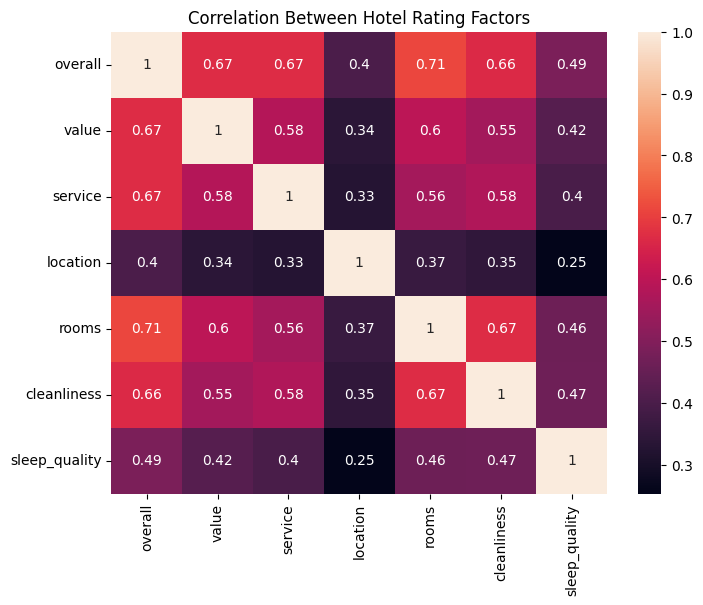

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['overall','value','service','location',
        'rooms','cleanliness','sleep_quality']].corr(),
    annot=True
)

plt.title("Correlation Between Hotel Rating Factors")
plt.show()

TEXT ANALYSIS


In [20]:
!pip install wordcloud

In [21]:
from wordcloud import WordCloud

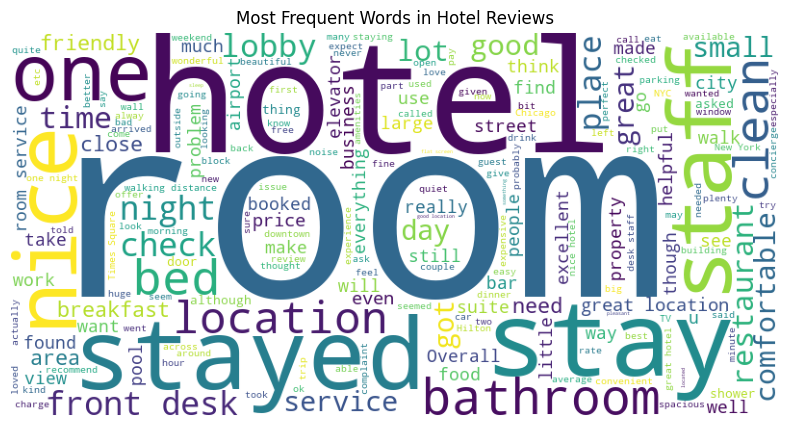

In [22]:

import matplotlib.pyplot as plt

text = " ".join(df['review_text'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Hotel Reviews")
plt.show()

In [23]:
!pip install textblob

In [24]:
from textblob import TextBlob

In [25]:
import sys
!{sys.executable} -m pip install textblob


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\muska\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [26]:
from textblob import TextBlob

In [27]:
!python -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to C:\Users\muska/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\muska/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to C:\Users\muska/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\muska/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\muska/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\muska/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [28]:
df['sentiment_score'] = df['review_text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [29]:
def get_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

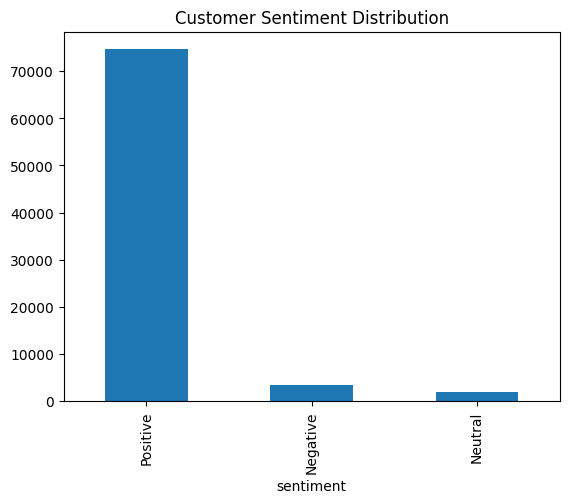

In [30]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment Distribution")
plt.show()

Key Insights from Hotel Review Analysis

Most hotel reviews express positive sentiment, indicating high overall customer satisfaction.

Location, cleanliness, and room quality show strong correlation with overall ratings.

Longer reviews tend to appear across all rating levels, suggesting engaged customer feedback.

Text analysis highlights frequently mentioned aspects such as room, staff, location, and service.